In [91]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import plotly.express as px
import nbformat

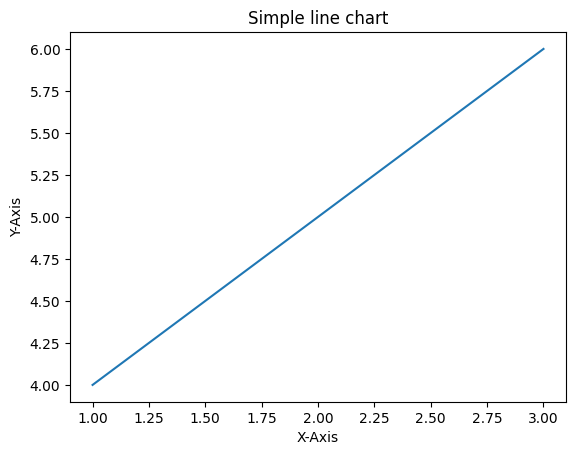

In [4]:
fig, ax = plt.subplots()

ax.plot([1,2,3],[4,5,6])

ax.set_title("Simple line chart")
ax.set_xlabel("X-Axis")
ax.set_ylabel("Y-Axis")

plt.show()

In [6]:
df = pd.read_csv("Superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1.0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2.0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3.0,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4.0,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5.0,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   float64
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
 18  Quantity       9994

In [8]:
df.dropna(inplace = True)

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9789 non-null   float64
 1   Order ID       9789 non-null   str    
 2   Order Date     9789 non-null   str    
 3   Ship Date      9789 non-null   str    
 4   Ship Mode      9789 non-null   str    
 5   Customer ID    9789 non-null   str    
 6   Customer Name  9789 non-null   str    
 7   Segment        9789 non-null   str    
 8   Country        9789 non-null   str    
 9   City           9789 non-null   str    
 10  State          9789 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9789 non-null   str    
 13  Product ID     9789 non-null   str    
 14  Category       9789 non-null   str    
 15  Sub-Category   9789 non-null   str    
 16  Product Name   9789 non-null   str    
 17  Sales          9789 non-null   float64
 18  Quantity       9789 non-

In [ ]:
sales_by_category = df.groupby('Category')[['Sales']].sum().sort_values('Sales',ascending=False)
sales_by_category

,Sales
Category,
Technology,825856.1130
Furniture,723538.4757
Office Supplies,703212.8240


Bar Chart

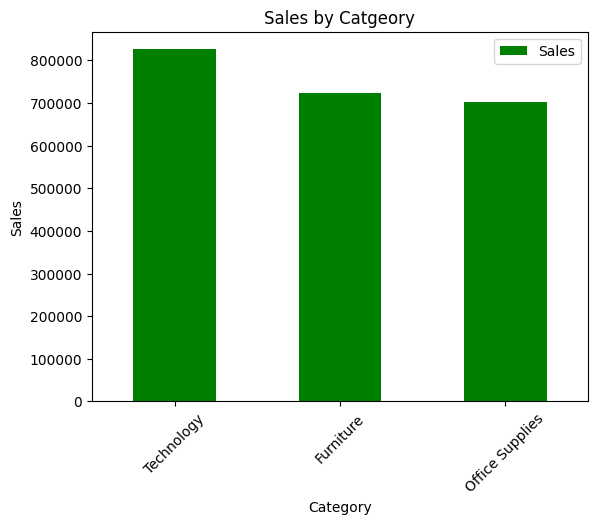

In [19]:
sales_by_category.plot(kind = 'bar', color = 'green')

plt.title('Sales by Catgeory')
plt.ylabel('Sales')
plt.xticks(rotation = 45)

plt.show()


TypeError: Axis.set_ticks() missing 1 required positional argument: 'ticks'

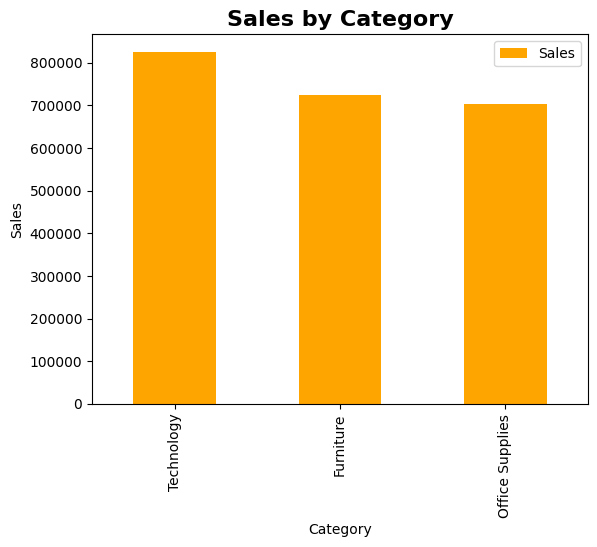

In [28]:
sales_by_category
ax = sales_by_category.plot(kind='bar',color = 'orange')

ax.set_title('Sales by Category',fontsize = 16,fontweight = 'bold')
ax.set_ylabel('Sales')
ax.set_xticks(rotation = 45)
plt.show()

Pie Chart

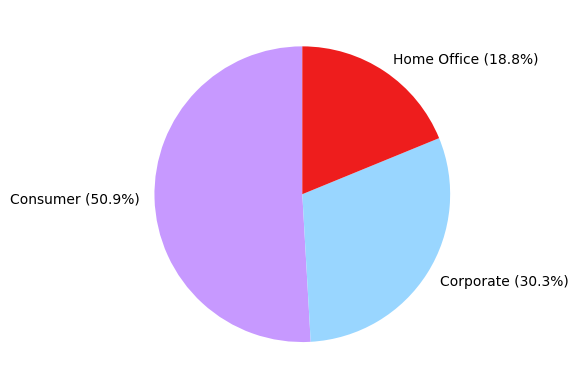

In [42]:
import matplotlib.pyplot as plt

sales_by_segment = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

total = sales_by_segment.sum()
percentages = (sales_by_segment/total) * 100

label = [f"{seg} ({pct}%)" for seg, pct in zip(sales_by_segment.index, percentages.round(1))]

sales_by_segment.plot(
    kind='pie',        
    startangle=90,
    labels = label,
    colors=["#c799ff", "#99d6ff", "#ee1d1d"], 
    legend=False
)
plt.ylabel('') 
plt.show()

Histogram

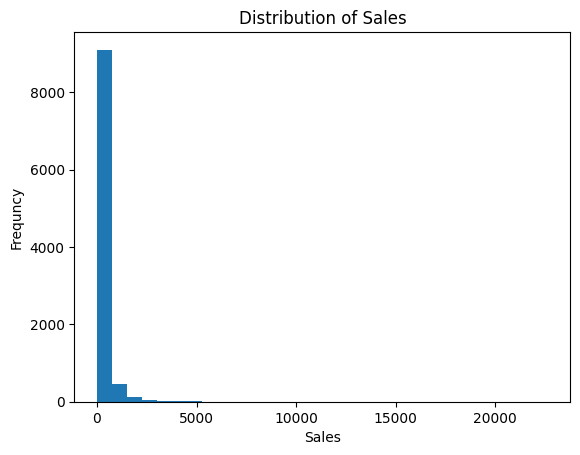

In [44]:
plt.hist(df['Sales'], bins = 30)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequncy')

plt.show()

Horizontal Bar Chart

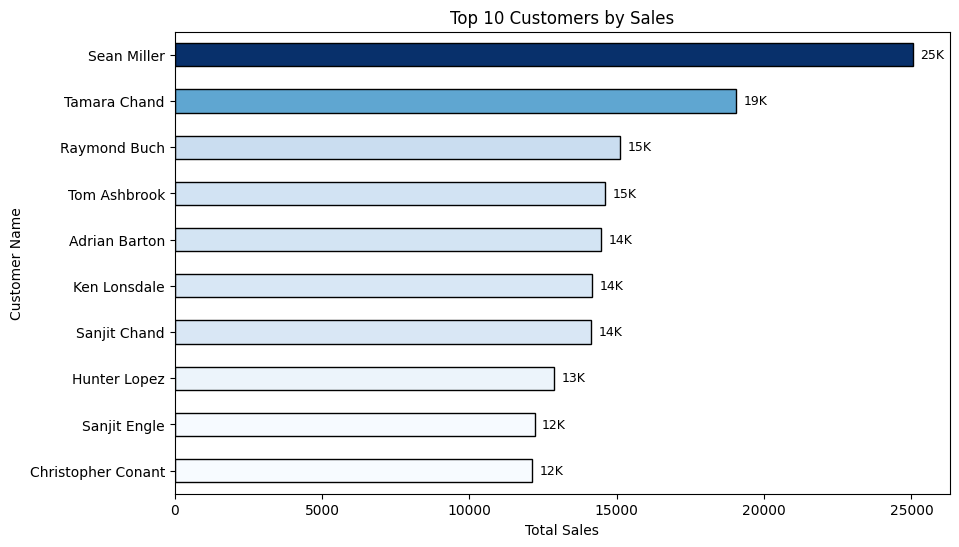

In [62]:
top_customers = df.groupby('Customer Name')['Sales'].sum().nlargest(10).sort_values(ascending = True)
ax = top_customers.plot(kind = 'barh', color = colors, edgecolor = 'black', figsize = (10,6))
ax.set_title('Top 10 Customers by Sales')
ax.set_xlabel('Total Sales')

norm = mcolors.Normalize(vmin = top_customers.min(),vmax =top_customers.max())
colors = cm.Blues(norm(top_customers.values))
for i,value in enumerate(top_customers):
    label = f"{value/1000:.0f}K"
    ax.text(value + top_customers.max() * 0.01,i,label, va = 'center', ha = 'left', fontsize = 9)

plt.show()

Scatter plot

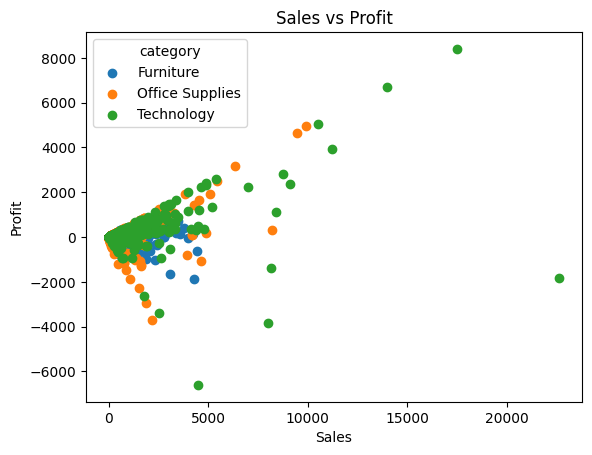

In [69]:
category = df['Category'].unique()

for cat in category:
    subset = df[df['Category'] == cat]
    plt.scatter(subset['Sales'],subset['Profit'], label=cat)

plt.legend(title = 'category')
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

Trend line

In [75]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst = True)


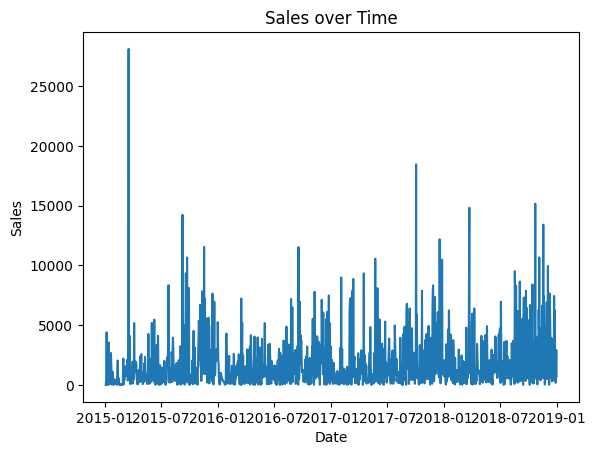

In [78]:
sales_over_time = df.groupby('Order Date')['Sales'].sum()
plt.plot(sales_over_time)
plt.title('Sales over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

In [79]:
df = df.set_index('Order Date')
df

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2017-11-08,1.0,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2017-11-08,2.0,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2017-06-12,3.0,CA-2017-138688,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
2016-10-11,4.0,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
2016-10-11,5.0,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-05-21,9796.0,CA-2017-125920,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,3,0.80,-5.8869
2016-01-12,9797.0,CA-2016-128608,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,2,0.20,1.5552
2016-01-12,9798.0,CA-2016-128608,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880,2,0.40,-43.1178


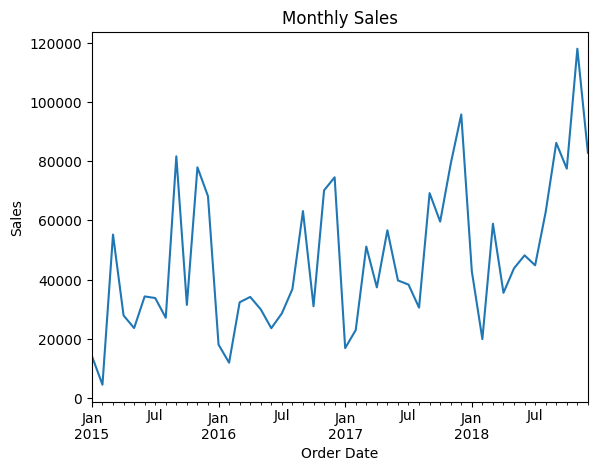

In [81]:
monthly_sales = df['Sales'].resample('ME').sum()
monthly_sales.plot(title = 'Monthly Sales', xlabel = 'Order Date', ylabel = 'Sales')
plt.show()

In [82]:
df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2017-11-08,1.0,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2017-11-08,2.0,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2017-06-12,3.0,CA-2017-138688,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
2016-10-11,4.0,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
2016-10-11,5.0,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [83]:
df.loc['11/10/2016']

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2016-11-10,266.0,CA-2016-155040,15/11/2016,Standard Class,AH-10210,Alan Hwang,Consumer,United States,Brentwood,California,94513.0,West,TEC-AC-10004469,Technology,Accessories,Microsoft Sculpt Comfort Mouse,79.900,2,0.0,35.1560
2016-11-10,5006.0,CA-2016-158659,14/11/2016,Second Class,SC-20695,Steve Chapman,Corporate,United States,Richmond,Indiana,47374.0,Central,OFF-ST-10003306,Office Supplies,Storage,Letter Size Cart,714.300,5,0.0,207.1470
2016-11-10,5849.0,CA-2016-121783,14/11/2016,Standard Class,PO-19180,Philisse Overcash,Home Office,United States,Roseville,Minnesota,55113.0,Central,OFF-AP-10003849,Office Supplies,Appliances,Hoover Shoulder Vac Commercial Portable Vacuum,715.640,2,0.0,178.9100
2016-11-10,5850.0,CA-2016-121783,14/11/2016,Standard Class,PO-19180,Philisse Overcash,Home Office,United States,Roseville,Minnesota,55113.0,Central,OFF-ST-10000078,Office Supplies,Storage,Tennsco 6- and 18-Compartment Lockers,795.510,3,0.0,143.1918
2016-11-10,5851.0,CA-2016-121783,14/11/2016,Standard Class,PO-19180,Philisse Overcash,Home Office,United States,Roseville,Minnesota,55113.0,Central,TEC-CO-10001571,Technology,Copiers,Sharp 1540cs Digital Laser Copier,549.990,1,0.0,274.9950
2016-11-10,5852.0,CA-2016-121783,14/11/2016,Standard Class,PO-19180,Philisse Overcash,Home Office,United States,Roseville,Minnesota,55113.0,Central,OFF-BI-10001658,Office Supplies,Binders,GBC Standard Therm-A-Bind Covers,74.760,3,0.0,34.3896
2016-11-10,5853.0,CA-2016-121783,14/11/2016,Standard Class,PO-19180,Philisse Overcash,Home Office,United States,Roseville,Minnesota,55113.0,Central,FUR-FU-10004351,Furniture,Furnishings,Staple-based wall hangings,29.220,3,0.0,12.8568
2016-11-10,9552.0,CA-2016-147690,14/11/2016,Standard Class,SC-20020,Sam Craven,Consumer,United States,Philadelphia,Pennsylvania,19140.0,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,577.584,6,0.2,43.3188


In [ ]:
df['Delivery Days'] = (df['Ship Date'] - df.index).dt.days

In [84]:
df['Order Date'] = df.index

In [85]:
df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Date
Order Date,,,,,,,,,,,,,,,,,,,,,
2017-11-08,1.0,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2017-11-08
2017-11-08,2.0,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2017-11-08
2017-06-12,3.0,CA-2017-138688,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2017-06-12
2016-10-11,4.0,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2016-10-11
2016-10-11,5.0,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2016-10-11


In [86]:
df['Order Date'] = pd.to_datetime(df['Order Date'])  
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst = True) 

In [ ]:
df['Delivery Days'] = (df['Ship Date'] - df.index).dt.days


In [89]:
df[['Order Date','Ship Date','Delivery Days']]

,Order Date,Ship Date,Delivery Days
Order Date,,,
2017-11-08,2017-11-08,2017-11-11,3
2017-11-08,2017-11-08,2017-11-11,3
2017-06-12,2017-06-12,2017-06-16,4
2016-10-11,2016-10-11,2016-10-18,7
2016-10-11,2016-10-11,2016-10-18,7
...,...,...,...
2017-05-21,2017-05-21,2017-05-28,7
2016-01-12,2016-01-12,2016-01-17,5
2016-01-12,2016-01-12,2016-01-17,5


In [93]:
print(nbformat.__version__)

5.10.4


Plolty for Interactivity

In [94]:
df = px.data.gapminder()
df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   continent  1704 non-null   str    
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   str    
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 106.6 KB


In [96]:
df['country'].unique()

<StringArray>
[       'Afghanistan',            'Albania',            'Algeria',
             'Angola',          'Argentina',          'Australia',
            'Austria',            'Bahrain',         'Bangladesh',
            'Belgium',
 ...
             'Uganda',     'United Kingdom',      'United States',
            'Uruguay',          'Venezuela',            'Vietnam',
 'West Bank and Gaza',        'Yemen, Rep.',             'Zambia',
           'Zimbabwe']
Length: 142, dtype: str

In [101]:
df_east_africa = df[df['country'].isin(['Kenya', 'Uganda', 'Tanzania'])]

fig = px.line(df_east_africa, x='year', y='gdpPercap', color='country', 
              title = 'GPP Per Capita in East Africa')
fig.show()

In [102]:
df_2007 = df[df['year'] == 2007]

In [107]:
fig = px.scatter(df_2007, x='gdpPercap', y='lifeExp', color='continent',
              size = 'pop', hover_name = 'country', log_x = True,
              title = 'GPP Per Capita in East Africa')
fig.show()

In [109]:
df_bar = df_2007.groupby('continent')['pop'].sum().reset_index().sort_values(by='pop',ascending = False)

In [113]:
fig = px.bar(df_bar, x='continent', y='pop',title = 'Population by Continent (2007)')
fig.show()

In [115]:
fig = px.box(df_2007, x = 'continent', y = 'lifeExp',points = 'all', title = 'Life Expectancy (2007)')
fig.show()  

In [117]:
fig = px.choropleth(df_2007, locations = 'iso_alpha', color = 'lifeExp',
                    title = 'Life Expectancy by Country (2007)')
fig.show()

In [121]:
fig = px.scatter(df,x = 'gdpPercap', y = 'lifeExp',color = 'continent',
                 size = 'pop', hover_name= 'country', title = 'GDP vs Life Expectancy', 
                 animation_frame = 'year', animation_group = 'country', log_x = True,
                 size_max = 60)
fig.show()